   Fold  Accuracy
0     1  0.637500
1     2  0.637125
2     3  0.635750
3     4  0.628000
4     5  0.634375


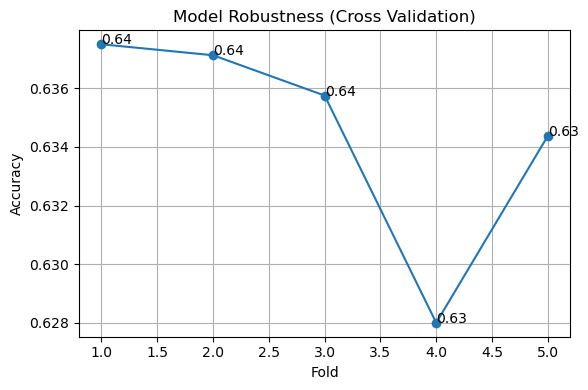

In [4]:

# RQ6: Robustness using Cross Validation

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# 1. LOAD DATA

df = pd.read_csv('D:/University Of Europe/ML/Assignment 1/Cyber Security Attacks Dataset.csv')

target = 'Attack Type'

df = df.dropna()


# 2. PREPROCESS 

# Remove high-cardinality columns
threshold = 50
df = df.drop(columns=[col for col in df.columns if df[col].nunique() > threshold])

X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
y = df[target]

# Convert to binary (same as before)
top_class = y.value_counts().index[0]
y = (y == top_class).astype(int)

# 3. MODEL

model = RandomForestClassifier(random_state=42)

# 4. CROSS VALIDATION

scores = cross_val_score(model, X, y, cv=5)

df_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": scores
})

print(df_results)

df_results.to_csv("RQ6_cv_results.csv", index=False)


# 5. PLOT

plt.figure(figsize=(6,4))
plt.plot(df_results["Fold"], df_results["Accuracy"], marker='o')

for i, v in enumerate(df_results["Accuracy"]):
    plt.text(i+1, v, f"{v:.2f}")

plt.title("Model Robustness (Cross Validation)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.grid(True)
plt.tight_layout()
plt.savefig("RQ6_cv_plot.pdf")
plt.show()